In [55]:
import pyvisa
import json
import time
import matplotlib.pyplot as plt
import os
import numpy as np
from datetime import datetime

In [32]:
rm = pyvisa.ResourceManager()
rm.list_resources()

('ASRL3::INSTR', 'ASRL4::INSTR', 'GPIB0::15::INSTR')

In [33]:
tc = rm.open_resource('GPIB0::15::INSTR') #temperature controller instance

In [34]:
tc.query('*IDN?')

'+LSCI,MODEL331S,331162,121300\r\n'

In [35]:
temperature = {}
temperature['A'] = float(tc.query('KRDG? A'))
temperature['B'] = float(tc.query('KRDG? B'))
temperature['datetime'] = datetime.today().strftime('%Y-%m-%d %H:%M:%S')
temperature['unit'] = "K"
temperature

{'A': 294.36, 'B': 294.2, 'datetime': '2026-02-27 11:08:46', 'unit': 'K'}

In [51]:
thermometer = {}
thermometer['sensor'] = "Lakeshore diodes"
thermometer['jupyter'] = "global jupyter notebook github url"
thermometer['location'] = "Boulder low temperature labs"
file_object = open("thermometer.json", "w")
file_object.write(json.dumps(thermometer))
file_object.close()
thermometer

{'sensor': 'Lakeshore diodes',
 'jupyter': 'global jupyter notebook github url',
 'location': 'Boulder low temperature labs'}

In [52]:
seconds_per_point = 10
number_of_points = 180
temperature_log = {}
temperature_log['A'] = []
temperature_log['B'] = []
temperature_log['seconds'] = []
temperature_log['filename'] = "temperature_log_" + datetime.today().strftime('%Y_%m_%d_%H_%M_%S') + ".json"
temperature_log['epoch_start'] = time.time()
temperature_log['unit'] = temperature['unit']
temperature_log['thermometer'] = thermometer
temperature_log['year'] = datetime.today().strftime('%Y')
temperature_log['month'] = datetime.today().strftime('%m')
temperature_log['day'] = datetime.today().strftime('%d')
temperature_log['timezone'] = "UTC-7"
temperature_log['time'] = datetime.today().strftime('%H:%M:%S')

for index in range(number_of_points):
    temperature = {}
    temperature['A'] = float(tc.query('KRDG? A'))
    temperature['B'] = float(tc.query('KRDG? B'))
    temperature['datetime'] = datetime.today().strftime('%Y-%m-%d %H:%M:%S')
    temperature['unit'] = "K"
    print(json.dumps(temperature))
    file_object = open("temperature.json", "w")
    file_object.write(json.dumps(temperature))
    file_object.close()
    temperature_log['A'].append(temperature['A'])
    temperature_log['B'].append(temperature['B'])
    temperature_log['seconds'].append(time.time() - temperature_log['epoch_start'])
    file_object = open(temperature_log['filename'], "w")
    file_object.write(json.dumps(temperature_log))
    file_object.close()
    file_object = open("temperature_log.json", "w")
    file_object.write(json.dumps(temperature_log))
    file_object.close()
    time.sleep(seconds_per_point)

{"A": 294.44, "B": 294.27, "datetime": "2026-02-27 11:20:35", "unit": "K"}
{"A": 294.44, "B": 294.27, "datetime": "2026-02-27 11:20:45", "unit": "K"}
{"A": 294.44, "B": 294.27, "datetime": "2026-02-27 11:20:55", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:21:05", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:21:15", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:21:25", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:21:35", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:21:45", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:21:55", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:22:05", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:22:15", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:22:25", "unit": "K"}
{"A": 294.44, "B": 294.28, "datetime": "2026-02-27 11:22:35", "unit": "K"}
{"A": 294.44, "B": 294.28

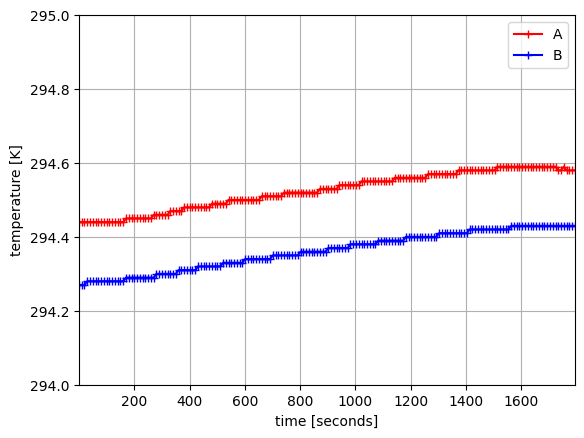

In [66]:
plt.plot(np.array(temperature_log['seconds']),np.array(temperature_log['A']),marker='+',color='red')
plt.plot(np.array(temperature_log['seconds']),np.array(temperature_log['B']),marker='+',color='blue')

plt.grid()
plt.xlim([temperature_log['seconds'][0],temperature_log['seconds'][len(temperature_log['seconds']) - 1]])
plt.ylim([294,295])
plt.xlabel('time [seconds]')
plt.ylabel('temperature [' + temperature_log['unit'] + ']')
plt.legend(['A','B'])


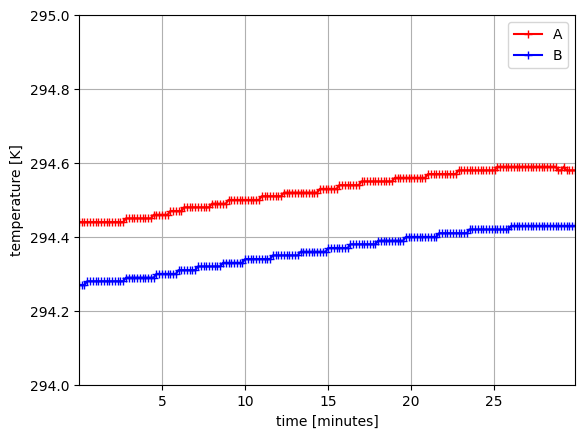

In [67]:
plt.plot(np.array(temperature_log['seconds'])/60,np.array(temperature_log['A']),marker='+',color='red')
plt.plot(np.array(temperature_log['seconds'])/60,np.array(temperature_log['B']),marker='+',color='blue')

plt.grid()
plt.xlim([temperature_log['seconds'][0]/60,temperature_log['seconds'][len(temperature_log['seconds']) - 1]/60])
plt.ylim([294,295])
plt.xlabel('time [minutes]')
plt.ylabel('temperature [' + temperature_log['unit'] + ']')
plt.legend(['A','B'])

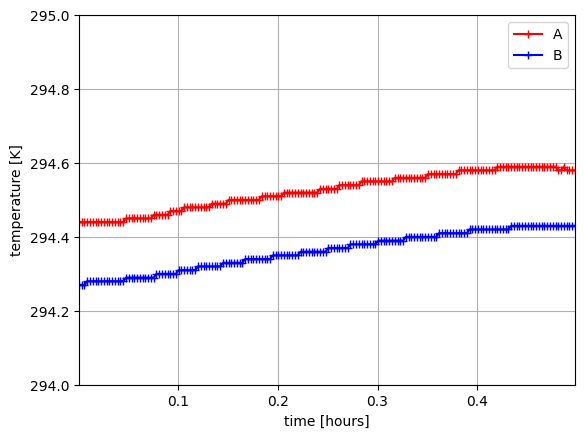

In [68]:
plt.plot(np.array(temperature_log['seconds'])/3600,np.array(temperature_log['A']),marker='+',color='red')
plt.plot(np.array(temperature_log['seconds'])/3600,np.array(temperature_log['B']),marker='+',color='blue')

plt.grid()
plt.xlim([temperature_log['seconds'][0]/3600,temperature_log['seconds'][len(temperature_log['seconds']) - 1]/3600])
plt.ylim([294,295])
plt.xlabel('time [hours]')
plt.ylabel('temperature [' + temperature_log['unit'] + ']')
plt.legend(['A','B'])